In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
plt.style.use('fivethirtyeight') # 

We read the testing and training data obtained from the OEDI website. 

In [29]:
df_test = pd.read_csv('../Data/test_data.csv')
df_train = pd.read_csv('../Data/training_data.csv')

In [30]:
# Rename columns for Prophet on BOTH dataframes

df_test = df_test.reset_index().rename(columns={
    'measured_on': 'ds',
    'actual_power_kw': 'y'
})

df_train = df_train.reset_index().rename(columns={
    'measured_on': 'ds',
    'actual_power_kw': 'y'
})

In [32]:
# Convert to UTC then strip timezone
df_train['ds'] = pd.to_datetime(df_train['ds'], utc=True).dt.tz_localize(None)
df_test['ds']  = pd.to_datetime(df_test['ds'],  utc=True).dt.tz_localize(None)



In [33]:
print(len(df_train))          # should be > 1000
print(df_train.columns.tolist())  # should include ds, y, irradiance, temperature, wind_speed
print(df_train['ds'].dtype)   # should be datetime64[ns]
print(df_test['ds'].dtype)    # should be datetime64[ns]

157630
['index', 'ds', 'poa_global', 'temp_air', 'wind_speed_mph', 'y']
datetime64[us]
datetime64[us]


In [41]:
# Define the split ratios for the cross-validation
ratios = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

results = []

for ratio in ratios:
    n = int(len(df_train) * ratio)
    train_fold = df_train.iloc[:n]

    # Setup and train model and fit
    model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05,   # controls trend flexibility
    )

    # Add the 3 features as regressors
    model.add_regressor('poa_global')
    model.add_regressor('temp_air')
    model.add_regressor('wind_speed_mph')

    model.fit(train_fold)

    forecast = model.predict(df_test)
    forecast_test = forecast[forecast['ds'].isin(df_test['ds'])]

    y_true = df_test['y'].values
    y_pred = forecast_test['yhat'].values

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    results.append({'train_ratio': f'{int(ratio*100)}%', 'train_size': n,
                    'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE': round(mape,2)})

# Summary table
results_df = pd.DataFrame(results)
print(results_df)

12:52:14 - cmdstanpy - INFO - Chain [1] start processing
12:52:36 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/qm/2s3tps9x6zs2vpgldtlz9rw80000gn/T/ipykernel_23583/1068378731.py:33: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
12:52:45 - cmdstanpy - INFO - Chain [1] start processing
12:53:06 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/qm/2s3tps9x6zs2vpgldtlz9rw80000gn/T/ipykernel_23583/1068378731.py:33: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
12:53:15 - cmdstanpy - INFO - Chain [1] start processing
12:53:43 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/qm/2s3tps9x6zs2vpgldtlz9rw80000gn/T/ipykernel_23583/1068378731.py:33: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
12:53:52 - cmdstanpy - INFO - Chain [1] start processing
12:54:24 - cmdstanp

  train_ratio  train_size     MAE    RMSE  MAPE
0         50%       78815   46.95   57.95   inf
1         60%       94578  267.87  273.13   inf
2         70%      110341   33.80   47.42   inf
3         80%      126104   48.11   59.18   inf
4         90%      141867   28.66   44.19   inf
5        100%      157630   28.89   43.95   inf


/var/folders/qm/2s3tps9x6zs2vpgldtlz9rw80000gn/T/ipykernel_23583/1068378731.py:33: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [42]:
# Use df_test set as future — it already has the regressor values
# Predict on test set
forecast = model.predict(df_test)
forecast_test = forecast[forecast['ds'].isin(df_test['ds'])]


# Key output columns
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

                   ds       yhat  yhat_lower  yhat_upper
0 2022-09-12 05:45:00 -18.030560  -74.493644   36.872202
1 2022-09-12 06:00:00 -16.626210  -70.897414   37.168328
2 2022-09-12 06:15:00 -14.662195  -66.609116   38.533276
3 2022-09-12 06:30:00 -11.643026  -67.450361   41.633612
4 2022-09-12 06:45:00  -7.552658  -63.600319   48.324542


In [48]:
# Evaluate

y_true = df_test['y'].values
y_pred = forecast['yhat'].values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"Ratio {int(ratio*100)}% | train size: {n} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")


Ratio 100% | train size: 157630 | MAE: 28.89 | RMSE: 43.95 | MAPE: inf%


/var/folders/qm/2s3tps9x6zs2vpgldtlz9rw80000gn/T/ipykernel_23583/713259793.py:8: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [49]:
# Summary table
results_df = pd.DataFrame(results)
print(results_df)

  train_ratio  train_size     MAE    RMSE  MAPE
0         50%       78815   46.95   57.95   inf
1         60%       94578  267.87  273.13   inf
2         70%      110341   33.80   47.42   inf
3         80%      126104   48.11   59.18   inf
4         90%      141867   28.66   44.19   inf
5        100%      157630   28.89   43.95   inf
6        100%      157630   28.89   43.95   inf
7        100%      157630   28.89   43.95   inf


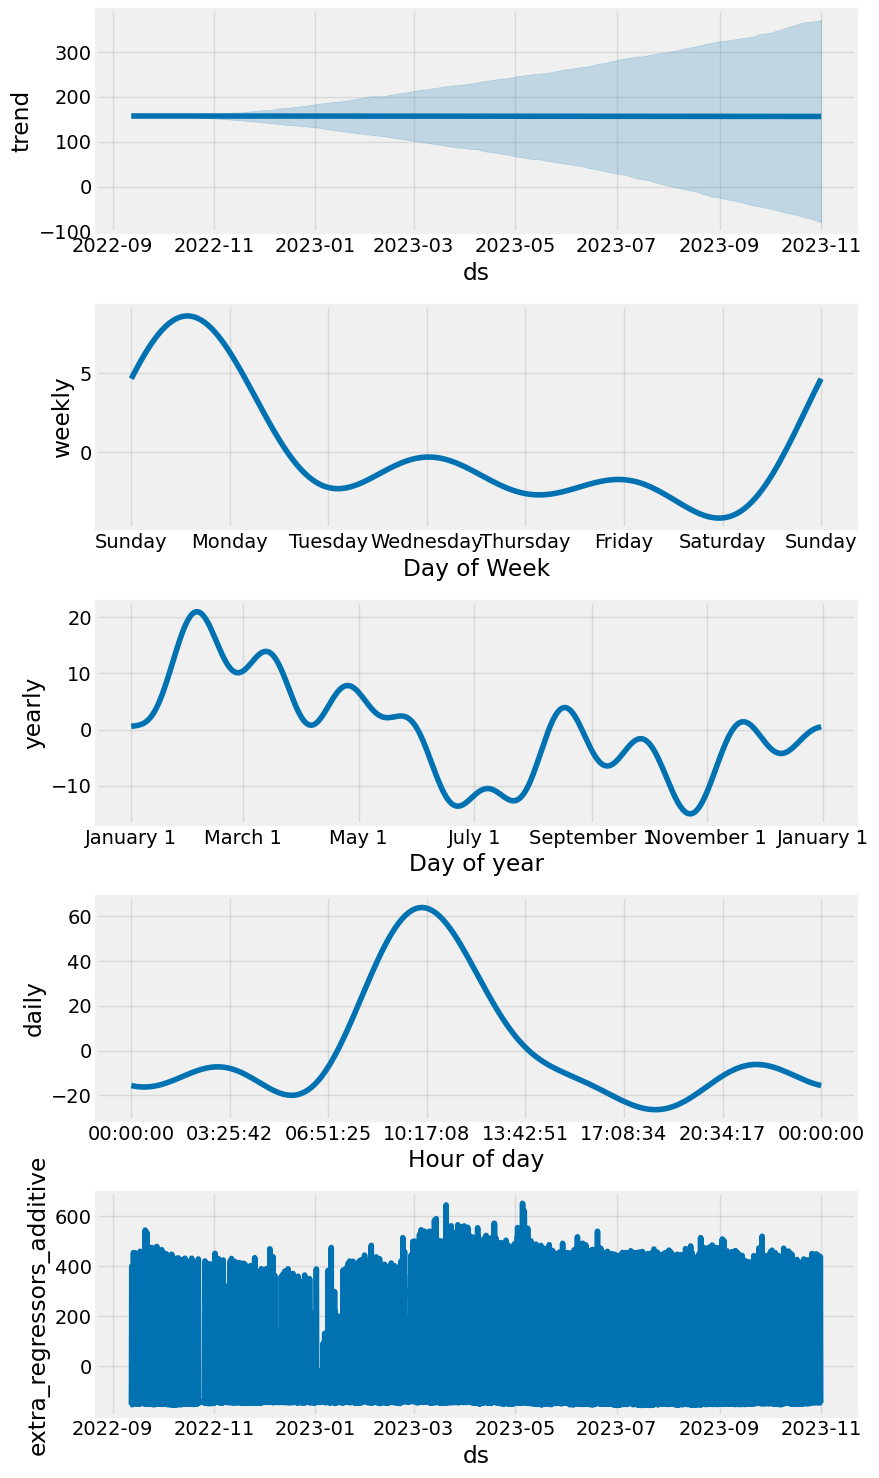

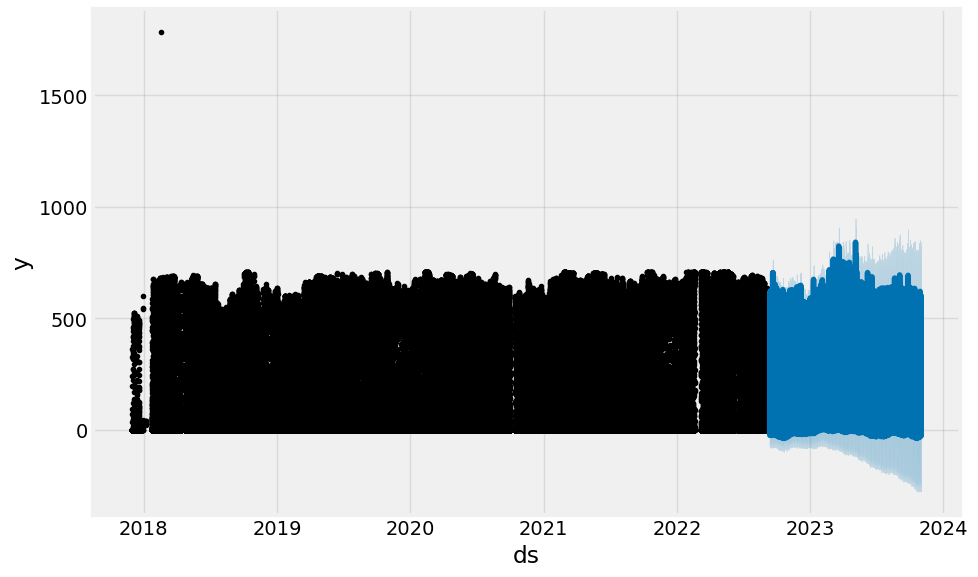

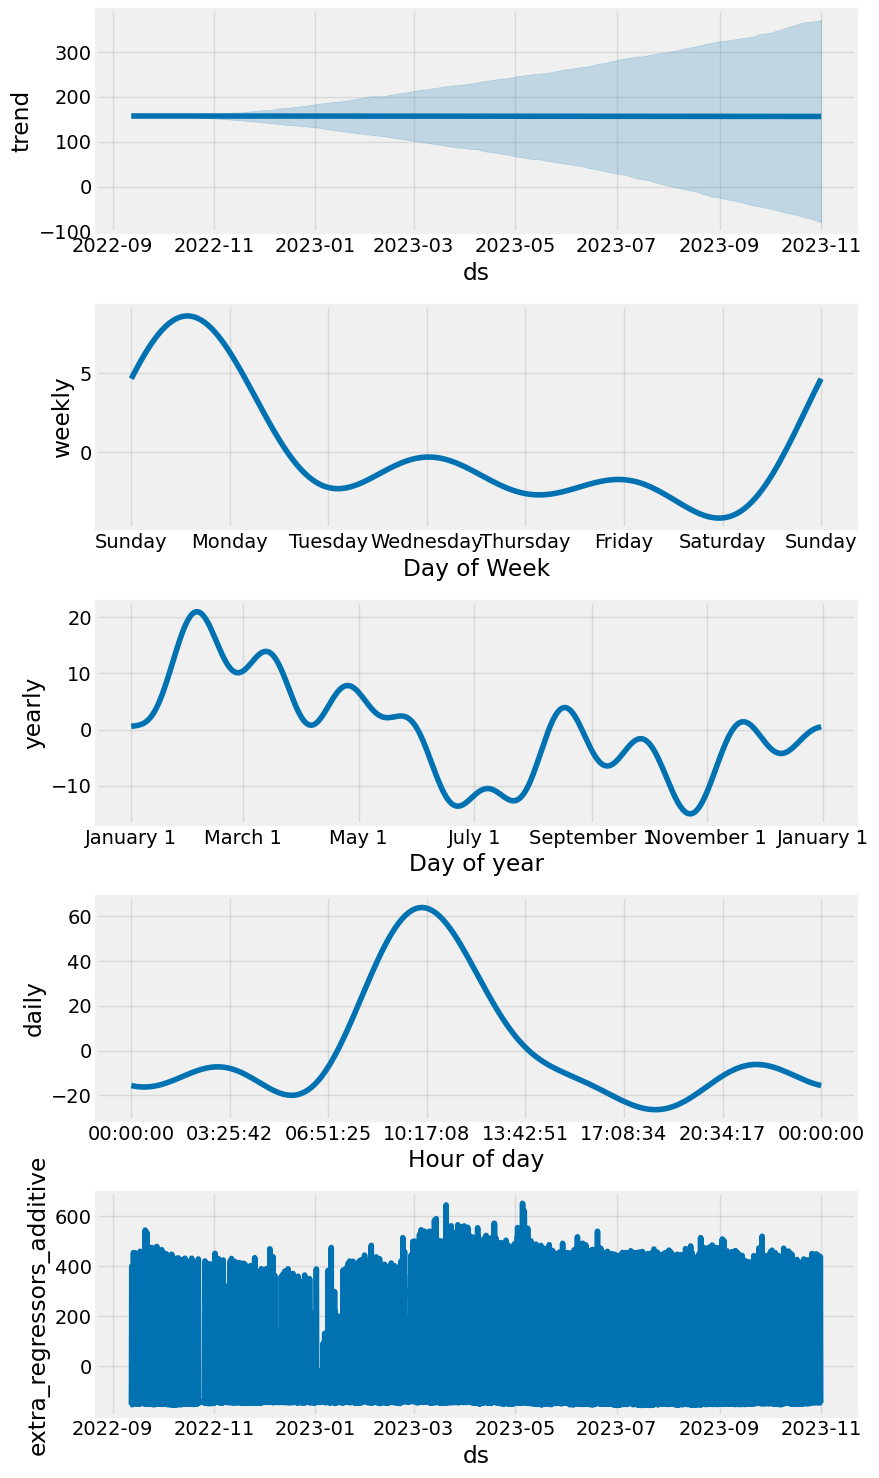

In [50]:
# Built-in Prophet plots
model.plot(forecast)
model.plot_components(forecast)   # shows trend, seasonality, regressor effects

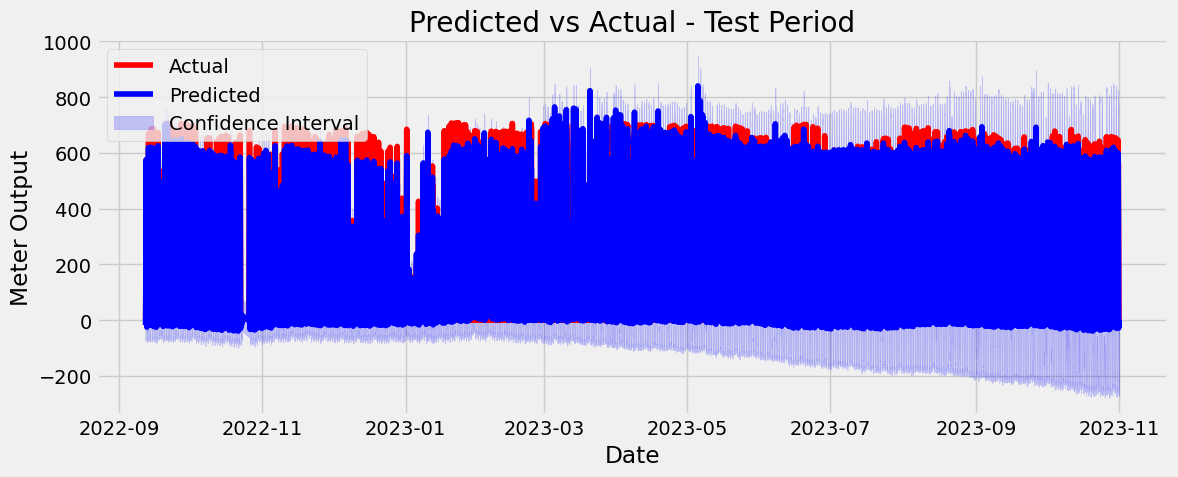

In [51]:
plt.figure(figsize=(12, 5))

# Actual values from test set
plt.plot(df_test['ds'], df_test['y'], color='red', label='Actual')

# Predicted values — filter forecast to test period only
forecast_test = forecast[forecast['ds'].isin(df_test['ds'])]
plt.plot(forecast_test['ds'], forecast_test['yhat'], color='blue', label='Predicted')

# Confidence interval
plt.fill_between(forecast_test['ds'],
                 forecast_test['yhat_lower'],
                 forecast_test['yhat_upper'],
                 alpha=0.2, color='blue', label='Confidence Interval')

plt.title('Predicted vs Actual - Test Period')
plt.xlabel('Date')
plt.ylabel('Meter Output')
plt.legend()
plt.tight_layout()
plt.show()